In [1]:
# ========================
# STD LIBS (Python nativo)
# ========================
import json
import time
import random
import subprocess
from pathlib import Path
from io import StringIO

# ==========================
# TERCEIROS (dados & web)
# ==========================
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup

# ==========================
# SELENIUM (automação web)
# ==========================
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException

# Opções para Firefox
from selenium.webdriver.firefox.options import Options


# ==========================
# VISUALIZAÇÃO (gráficos)
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

# ==========================
# JUPYTER MAGIC (Notebook)
# ==========================
%matplotlib inline

# ==========================
# AJUSTE PANDAS (exibir tudo)
# ==========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# ==========================
# ALERTAS (remover alertas)
# ==========================
import warnings
warnings.filterwarnings("ignore")


In [2]:


# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário 
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/comps/38/stats/Serie-B-Stats#all_stats_standard"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    tabela_brasileirao = table[11]
    print(tabela_brasileirao.head())

    # Exportar para CSV
    tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\raw\Player_Standard_Stats_2024_Serie_B.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[INFO] Tor iniciado com sucesso.
[INFO] Página de verificação do Tor carregada.
[1/1] Acessando: https://fbref.com/en/comps/38/stats/Serie-B-Stats#all_stats_standard
  Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player             Nation                Pos   
0                  1      Sabit Abdulai             gh GHA                 MF   
1                  2           Adaílton             br BRA              FW,MF   
2                  3        Lucas Adell             br BRA                 DF   
3                  4          Ademilson             br BRA              FW,MF   
4                  5             Adriel             br BRA                 GK   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Playing Time  \
               Squad                Age               Born           MP   
0      Botafogo (SP)             26-183               1999           16   
1               Remo             34-339  

In [3]:
tabela_brasileirao.head(2)

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player             Nation                Pos   
0                  1      Sabit Abdulai             gh GHA                 MF   
1                  2           Adaílton             br BRA              FW,MF   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Playing Time  \
               Squad                Age               Born           MP   
0      Botafogo (SP)             26-183               1999           16   
1               Remo             34-339               1990           16   

                   Performance                                 Per 90 Minutes  \
  Starts  Min  90s         Gls Ast G+A G-PK PK PKatt CrdY CrdR            Gls   
0     10  821  9.1           0   0   0    0  0     0    4    0           0.00   
1      9  778  8.6           1   1   2    1  0     0    0    0           0.12   

                           Unnamed: 24_level_0  
    Ast   G+A  G-PK G+A-PK             Matches  
0  0.00  0.00  0.00   0.00             Matches  
1  0.12  0.23  0.12   0.23             Matches

In [4]:
import pandas as pd

def clean_fbref_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Se colunas forem MultiIndex (FBRef), usa o 2º nível (nomes reais).
    - Para colunas cujo 1º nível == 'Per 90 Minutes', adiciona sufixo '_90'.
    - Mantém 'Performance' sem mudanças.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df  # nada a fazer

    new_cols = []
    for col in df.columns:
        # col é uma tupla (nivel0, nivel1)
        g = str(col[0]).strip() if len(col) > 1 else ""
        name = str(col[1]).strip() if len(col) > 1 else str(col[0]).strip()

        # Alguns vêm como 'Unnamed: 0_level_0' etc. -> ignora
        if g.lower().startswith("unnamed"):
            g = ""

        # Regra: apenas Per 90 Minutes ganha _90
        if g == "Per 90 Minutes":
            name = f"{name}_90"

        new_cols.append(name)

    df = df.copy()
    df.columns = new_cols
    return df


In [5]:
#limpando as colunas 
tabela_brasileirao = clean_fbref_cols(tabela_brasileirao)


In [6]:
tabela_brasileirao.head(2)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,Matches
0,1,Sabit Abdulai,gh GHA,MF,Botafogo (SP),26-183,1999,16,10,821,9.1,0,0,0,0,0,0,4,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Adaílton,br BRA,"FW,MF",Remo,34-339,1990,16,9,778,8.6,1,1,2,1,0,0,0,0,0.12,0.12,0.23,0.12,0.23,Matches


In [7]:
#salvando tabela cabeçalho limpo

tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\raw\stats_2024_Serie_B.csv', index=False)

In [12]:
serie_b = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\raw\stats_2024_Serie_B.csv', sep=',')

In [13]:
serie_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rk         829 non-null    object
 1   Player     829 non-null    object
 2   Nation     829 non-null    object
 3   Pos        829 non-null    object
 4   Squad      829 non-null    object
 5   Age        828 non-null    object
 6   Born       828 non-null    object
 7   MP         829 non-null    object
 8   Starts     829 non-null    object
 9   Min        829 non-null    object
 10  90s        829 non-null    object
 11  Gls        829 non-null    object
 12  Ast        829 non-null    object
 13  G+A        829 non-null    object
 14  G-PK       829 non-null    object
 15  PK         829 non-null    object
 16  PKatt      829 non-null    object
 17  CrdY       829 non-null    object
 18  CrdR       829 non-null    object
 19  Gls_90     829 non-null    object
 20  Ast_90     829 non-null    objec

In [14]:
serie_b.head(4)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,Matches
0,1,Sabit Abdulai,gh GHA,MF,Botafogo (SP),26-183,1999,16,10,821,9.1,0,0,0,0,0,0,4,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Adaílton,br BRA,"FW,MF",Remo,34-339,1990,16,9,778,8.6,1,1,2,1,0,0,0,0,0.12,0.12,0.23,0.12,0.23,Matches
2,3,Lucas Adell,br BRA,DF,Volta Redonda,25-118,2000,17,15,1298,14.4,0,0,0,0,0,0,3,0,0.00,0.00,0.00,0.00,0.00,Matches
3,4,Ademilson,br BRA,"FW,MF",Operário,31-305,1994,22,9,877,9.7,1,1,2,0,1,2,1,1,0.10,0.10,0.21,0.00,0.10,Matches


In [15]:
serie_b.tail(4)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,Matches
825,795,Yuri,br BRA,"DF,MF",Athletic,29-306,1996,24,19,1486,16.5,1,4,5,1,0,0,6,0,0.06,0.24,0.30,0.06,0.30,Matches
826,796,Diego Zabala,uy URU,"MF,FW",Amazonas,34-052,1991,17,9,796,8.8,0,3,3,0,0,0,2,0,0.00,0.34,0.34,0.00,0.34,Matches
827,797,Bruno Zapelli,ar ARG,MF,Ath Paranaense,23-177,2002,33,29,2423,26.9,4,6,10,3,1,1,5,0,0.15,0.22,0.37,0.11,0.33,Matches
828,798,Zeca,br BRA,DF,Coritiba,31-178,1994,31,28,2514,27.9,0,1,1,0,0,0,6,0,0.00,0.04,0.04,0.00,0.04,Matches


In [16]:
# Excluir a coluna "Matches"
serie_b.drop(columns=["Matches"], inplace=True, errors="ignore")

# Exibir as primeiras linhas para confirmar as alterações
display(serie_b.head(4))

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90
0,1,Sabit Abdulai,gh GHA,MF,Botafogo (SP),26-183,1999,16,10,821,9.1,0,0,0,0,0,0,4,0,0.00,0.00,0.00,0.00,0.00
1,2,Adaílton,br BRA,"FW,MF",Remo,34-339,1990,16,9,778,8.6,1,1,2,1,0,0,0,0,0.12,0.12,0.23,0.12,0.23
2,3,Lucas Adell,br BRA,DF,Volta Redonda,25-118,2000,17,15,1298,14.4,0,0,0,0,0,0,3,0,0.00,0.00,0.00,0.00,0.00
3,4,Ademilson,br BRA,"FW,MF",Operário,31-305,1994,22,9,877,9.7,1,1,2,0,1,2,1,1,0.10,0.10,0.21,0.00,0.10


In [17]:
serie_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rk         829 non-null    object
 1   Player     829 non-null    object
 2   Nation     829 non-null    object
 3   Pos        829 non-null    object
 4   Squad      829 non-null    object
 5   Age        828 non-null    object
 6   Born       828 non-null    object
 7   MP         829 non-null    object
 8   Starts     829 non-null    object
 9   Min        829 non-null    object
 10  90s        829 non-null    object
 11  Gls        829 non-null    object
 12  Ast        829 non-null    object
 13  G+A        829 non-null    object
 14  G-PK       829 non-null    object
 15  PK         829 non-null    object
 16  PKatt      829 non-null    object
 17  CrdY       829 non-null    object
 18  CrdR       829 non-null    object
 19  Gls_90     829 non-null    object
 20  Ast_90     829 non-null    objec

In [18]:

def convert_fbref_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---- 1. Colunas categóricas (texto) ----
    text_cols = ["Player", "Nation", "Pos", "Squad"]

    # ---- 2. Coluna Rk -> int ----
    df["Rk"] = pd.to_numeric(df["Rk"], errors="coerce").astype("Int64")

    # ---- 3. Coluna Born -> ano (int) ----
    df["Born"] = pd.to_numeric(df["Born"], errors="coerce").astype("Int64")

    # ---- 4. Coluna Age -> anos + dias/365 ----
    def parse_age(age_str):
        try:
            years, days = age_str.split("-")
            val = int(years) + int(days) / 365
            return round(val, 2)   # arredonda para 2 casas decimais
        except:
            return pd.NA

    df["Age"] = df["Age"].astype(str).apply(parse_age).astype("Float64")

    # ---- 5. Todas as outras colunas (numéricas) ----
    num_cols = [c for c in df.columns if c not in text_cols + ["Rk", "Born", "Age"]]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").astype("Float64")

    return df


In [19]:
serie_b = convert_fbref_dtypes(serie_b)

In [20]:
serie_b.head(2)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90
0,1,Sabit Abdulai,gh GHA,MF,Botafogo (SP),26.5,1999,16.0,10.0,821.0,9.1,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Adaílton,br BRA,"FW,MF",Remo,34.93,1990,16.0,9.0,778.0,8.6,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.12,0.12,0.23,0.12,0.23


In [21]:
display(serie_b.dtypes)

Rk             Int64
Player        object
Nation        object
Pos           object
Squad         object
Age          Float64
Born           Int64
MP           Float64
Starts       Float64
Min          Float64
90s          Float64
Gls          Float64
Ast          Float64
G+A          Float64
G-PK         Float64
PK           Float64
PKatt        Float64
CrdY         Float64
CrdR         Float64
Gls_90       Float64
Ast_90       Float64
G+A_90       Float64
G-PK_90      Float64
G+A-PK_90    Float64
dtype: object

In [22]:
serie_b.isna().sum()

Rk           31
Player        0
Nation        0
Pos           0
Squad         0
Age          32
Born         32
MP           31
Starts       31
Min          31
90s          31
Gls          31
Ast          31
G+A          31
G-PK         31
PK           31
PKatt        31
CrdY         31
CrdR         31
Gls_90       31
Ast_90       31
G+A_90       31
G-PK_90      31
G+A-PK_90    31
dtype: int64

In [23]:
# Mostra apenas as linhas com pelo menos 1 NaN
df_nulls = serie_b[serie_b.isna().any(axis=1)]
print(df_nulls.shape)   
df_nulls.head()


(32, 24)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90
25,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
51,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
77,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
103,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
129,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


# Esses foram os cabecalhos de mudança de tabela, vamos excluir

In [24]:
# remove linhas onde Rk está vazio
serie_b = serie_b.dropna(subset=["Rk"]).reset_index(drop=True)


In [25]:
serie_b.isna().sum()

Rk           0
Player       0
Nation       0
Pos          0
Squad        0
Age          1
Born         1
MP           0
Starts       0
Min          0
90s          0
Gls          0
Ast          0
G+A          0
G-PK         0
PK           0
PKatt        0
CrdY         0
CrdR         0
Gls_90       0
Ast_90       0
G+A_90       0
G-PK_90      0
G+A-PK_90    0
dtype: int64

In [26]:
serie_b.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\standard_stats_b')

In [27]:
# Total de Gols - Excluindo Pênaltis
Total_Gols = serie_b['G-PK'].sum()
print(Total_Gols)

692.0


In [28]:
# Gols de Pênalti
Total_GolsPenalti = serie_b['PK'].sum()
print(Total_GolsPenalti)

84.0


In [29]:
# Tentativas de Pênalti
Total_TentativasPenalti = serie_b['PKatt'].sum()
print(Total_TentativasPenalti)

108.0


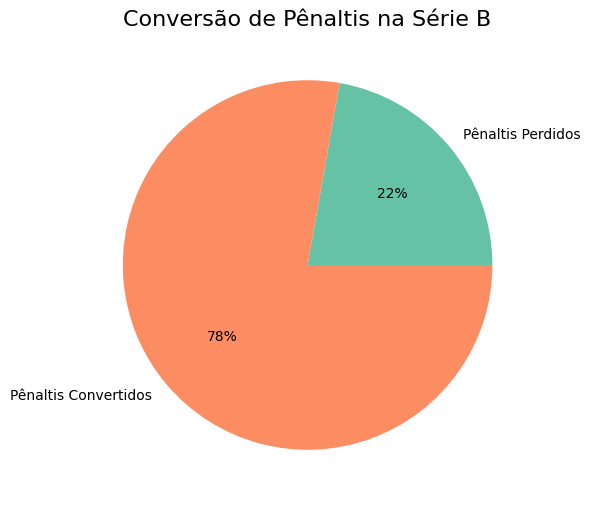

In [30]:
# Gráfico de pizza: pênaltis convertidos vs. desperdiçados
plt.figure(figsize=(13, 6))
plt_nao_convertidos = serie_b['PKatt'].sum() - Total_GolsPenalti  
dados = [plt_nao_convertidos, Total_GolsPenalti]
rotulos = ['Pênaltis Perdidos', 'Pênaltis Convertidos']
cores = sns.color_palette('Set2')

# Cria o gráfico de pizza
plt.pie(dados, labels=rotulos, colors=cores, autopct='%.0f%%')

# Adiciona o título
plt.title('Conversão de Pênaltis na Série B', fontsize=16)

# Exibe o gráfico
plt.show()

In [31]:
# Posições únicas

serie_b['Pos'].unique()

array(['MF', 'FW,MF', 'DF', 'GK', 'MF,FW', 'DF,MF', 'FW', 'MF,DF',
       'DF,FW'], dtype=object)

In [32]:
# Total de jogadores FW (atacantes)

serie_b[serie_b['Pos'] == 'FW']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90
20,21,Henrique Almeida,br BRA,FW,Amazonas,34.46,1991,26.0,21.0,1779.0,19.8,6.0,1.0,7.0,6.0,0.0,0.0,3.0,0.0,0.3,0.05,0.35,0.3,0.35
27,28,Daniel Alves,br BRA,FW,Atl Goianiense,20.93,2004,5.0,2.0,244.0,2.7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
28,29,Daniel Alves,br BRA,FW,CRB,20.93,2004,7.0,2.0,241.0,2.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,34,Daniel Amorim,br BRA,FW,Operário,36.15,1989,22.0,13.0,1029.0,11.4,7.0,1.0,8.0,6.0,1.0,1.0,2.0,0.0,0.61,0.09,0.7,0.52,0.61
39,40,Luan Andrey,br BRA,FW,Vila Nova,19.27,2006,1.0,0.0,28.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,49,Arthur,br BRA,FW,América (MG),22.67,2003,18.0,9.0,854.0,9.5,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.21,0.0,0.21,0.21,0.21
58,59,Pedro Balotelli,br BRA,FW,Novorizontino,20.82,2005,1.0,0.0,24.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,64,Facundo Barcelo,uy URU,FW,Goiás,32.61,1993,8.0,0.0,48.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
64,65,Facundo Barcelo,uy URU,FW,CRB,32.61,1993,6.0,3.0,243.0,2.7,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
70,71,Vitor Barreto,br BRA,FW,Ferroviária,25.61,2000,13.0,2.0,380.0,4.2,1.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,0.24,0.0,0.24,0.24,0.24


In [33]:
# Jogadores de diferentes nacionalidades

np.size((serie_b['Nation'].unique()))

19

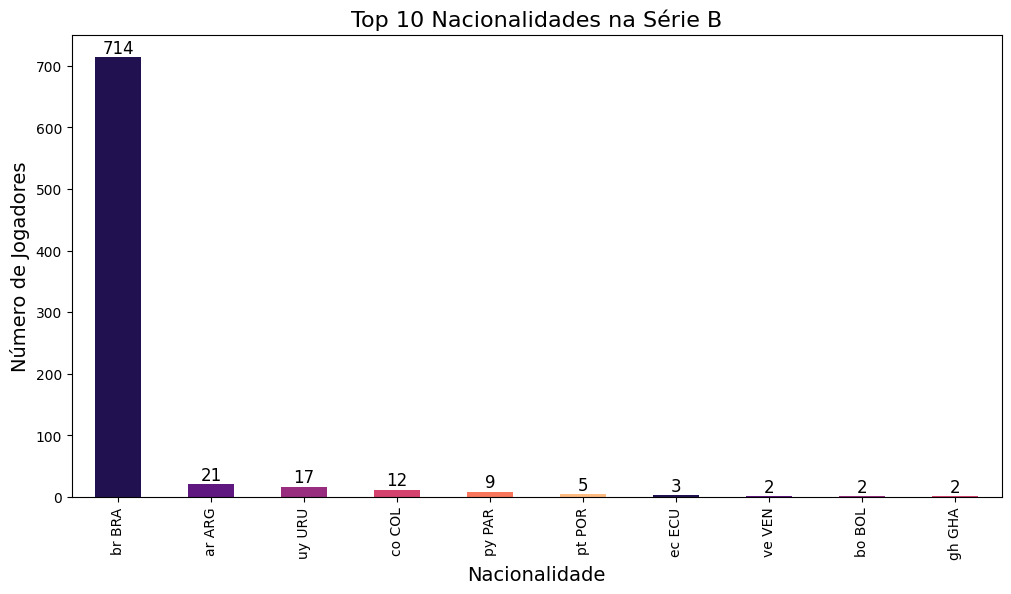

In [34]:
# Maior número de jogadores por país

# Agrupando e ordenando os dados
nacionalidade = serie_b.groupby('Nation').size().sort_values(ascending=False)

# Criando o gráfico de barras
ax = nacionalidade.head(10).plot(kind='bar', figsize=(12, 6), color=sns.color_palette("magma"))

# Adicionando os valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a ser exibido
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionando título e rótulos dos eixos
ax.set_title('Top 10 Nacionalidades na Série B', fontsize=16)
ax.set_xlabel('Nacionalidade', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibindo o gráfico
plt.show()

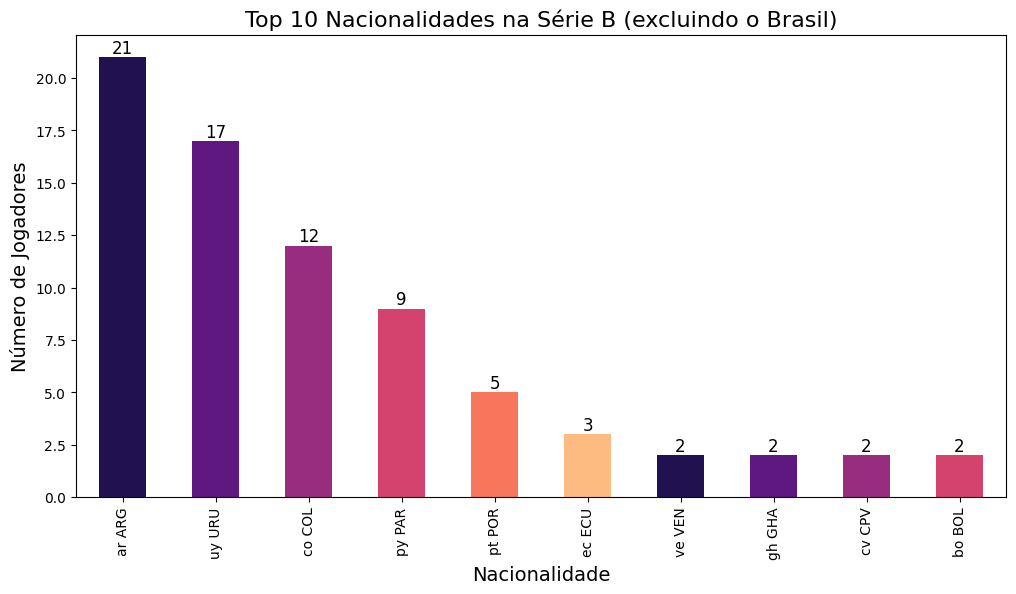

In [35]:
# Remover jogadores brasileiros (BRA)
serie_b_sem_brasileiros = serie_b[serie_b["Nation"] != "br BRA"]

# Agrupar e ordenar por nacionalidade
nacionalidade = serie_b_sem_brasileiros.groupby("Nation").size().sort_values(ascending=False)

# Plotar top 10
ax = nacionalidade.head(10).plot(
    kind="bar",
    figsize=(12, 6),
    color=sns.color_palette("magma")
)

# Adicionar valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black"
    )

# Títulos e rótulos dos eixos
ax.set_title("Top 10 Nacionalidades na Série B (excluindo o Brasil)", fontsize=16)
ax.set_xlabel("Nacionalidade", fontsize=14)
ax.set_ylabel("Número de Jogadores", fontsize=14)

plt.show()

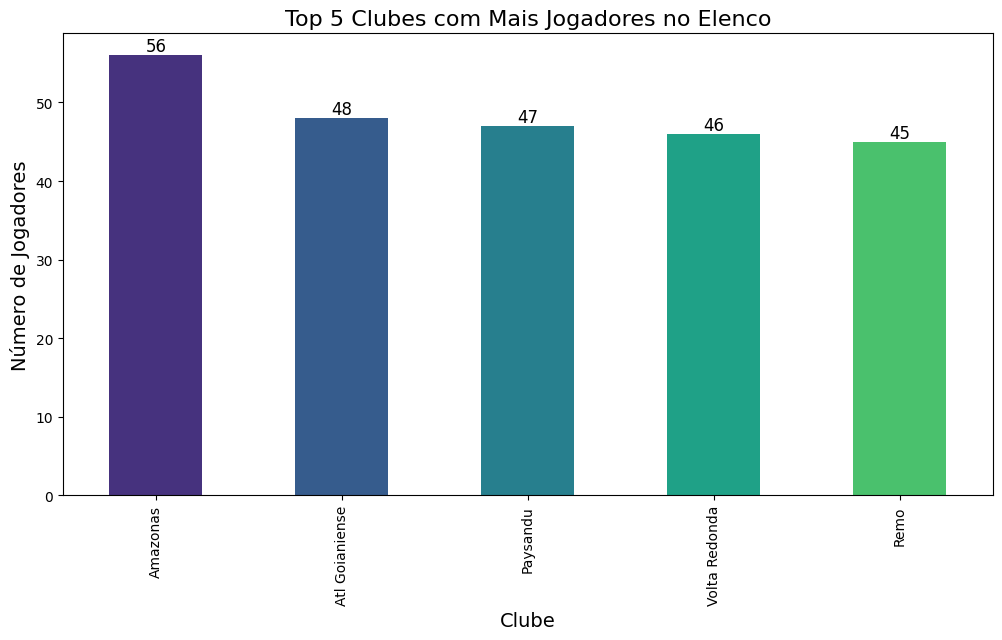

In [36]:
# Plotando os clubes com maior número de jogadores no elenco
plt.figure(figsize=(12, 6))
top_clubes = serie_b['Squad'].value_counts().nlargest(5)
ax = top_clubes.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Mais Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

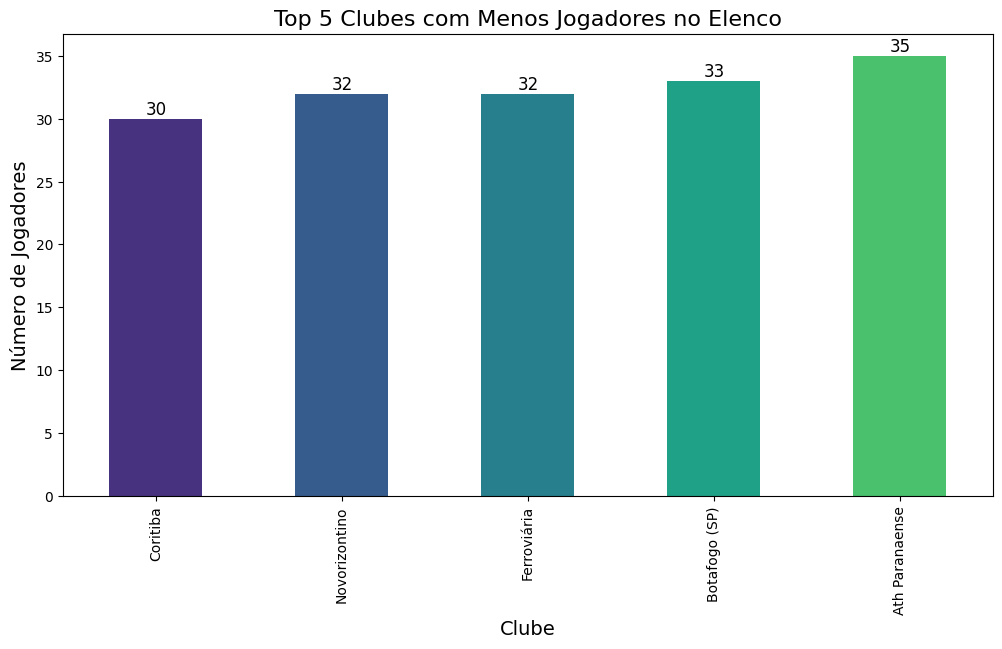

In [37]:
# Plotando os clubes com menor número de jogadores no elenco
plt.figure(figsize=(12, 6))
clubes_com_menos_jogadores = serie_b['Squad'].value_counts().nsmallest(5)
ax = clubes_com_menos_jogadores.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Menos Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

In [38]:
# Jogadores por faixa etária

Abaixo20 = serie_b[serie_b['Age'] <= 20]
Idade20_25 = serie_b[(serie_b['Age'] > 20) & (serie_b['Age'] <= 25)]
Idade25_30 = serie_b[(serie_b['Age'] > 25) & (serie_b['Age'] <= 30)]
Acima30 = serie_b[serie_b['Age'] > 30]

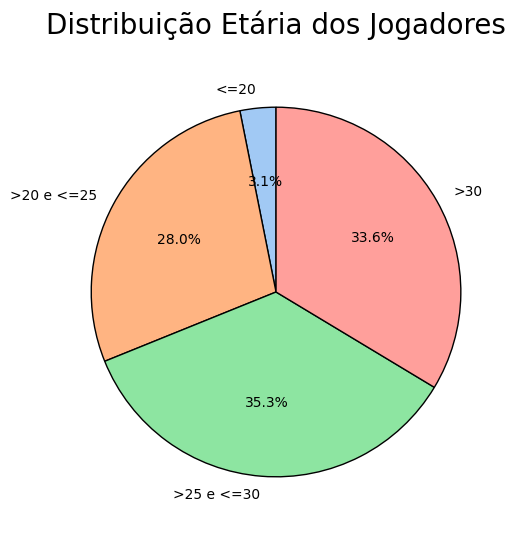

In [39]:
# Dados
x = np.array([
    Abaixo20['Player'].count(),
    Idade20_25['Player'].count(),
    Idade25_30['Player'].count(),
    Acima30['Player'].count()
])
rotulos = ["<=20", ">20 e <=25", ">25 e <=30", ">30"] 

# Criar paleta de cores personalizada
cores = sns.color_palette("pastel")

# Plotar gráfico de pizza
plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
plt.pie(
    x, 
    labels=rotulos, 
    autopct="%.1f%%", 
    colors=cores, 
    startangle=90,  # Rotacionar para começar no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar borda para melhor contraste
)
plt.title('Distribuição Etária dos Jogadores', fontsize=20, pad=20)  # Título traduzido + espaçamento

# Exibir o gráfico
plt.show()

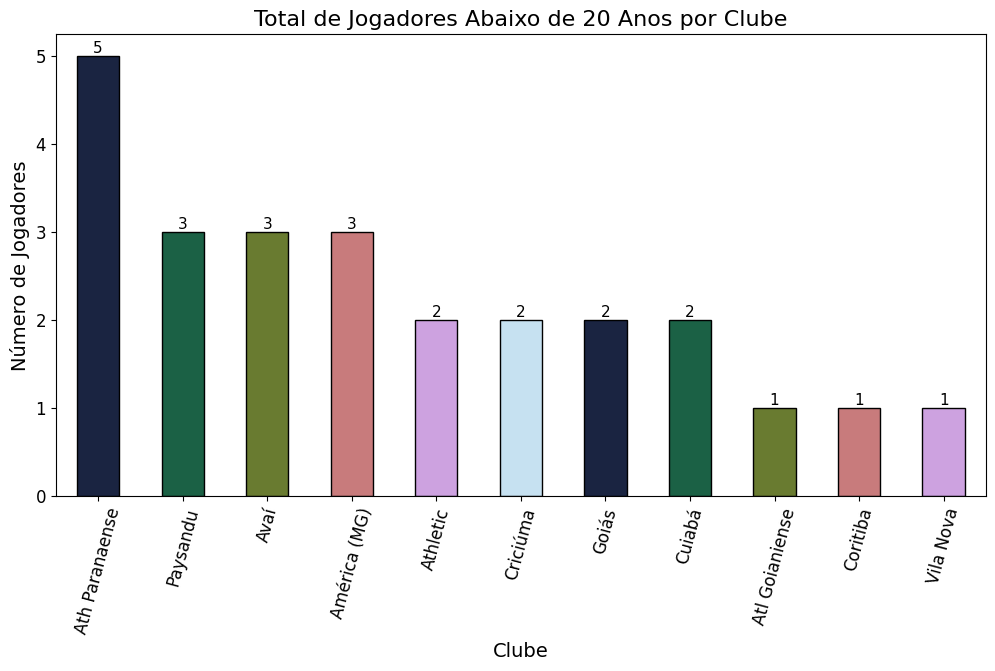

In [40]:
# Filtrar jogadores com menos de 20 anos
jogadores_abaixo_20 = serie_b[serie_b['Age'] < 20]

# Contar jogadores abaixo de 20 anos em cada clube
contagem_abaixo_20 = jogadores_abaixo_20['Squad'].value_counts()

# Plotar os dados
plt.figure(figsize=(12, 6))
ax = contagem_abaixo_20.plot(
    kind='bar', 
    color=sns.color_palette("cubehelix"), 
    edgecolor='black'
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir a contagem
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=11, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Total de Jogadores Abaixo de 20 Anos por Clube', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=75, fontsize=12)
plt.yticks(fontsize=12)

# Exibir o gráfico
plt.show()

In [ ]:
# Jogadores abaixo de 20 anos no Paysandu

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Paysandu']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90
111,112,Matheus Capixaba,br BRA,FW,Paysandu,19.68,2006,1.0,0.0,31.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
292,293,Pedro Gonçalves,br BRA,MF,Paysandu,18.01,2007,4.0,2.0,240.0,2.7,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
321,322,Kaua Hinkel,br BRA,MF,Paysandu,19.21,2006,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [129]:
# Jogadores abaixo de 20 anos no Palmeiras

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Palmeiras']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
70,71,Erick Belé,br BRA,MF,Palmeiras,18.75,2007,1.0,0.0,11.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71,72,Luis Benedetti,br BRA,DF,Palmeiras,19.37,2006,2.0,2.0,180.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.01,0.04,0.03,0.04
200,201,Luis Felipe,br BRA,MF,Palmeiras,17.72,2008,1.0,0.0,5.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
214,215,Riquelme Fillipi,br BRA,FW,Palmeiras,19.1,2006,1.0,0.0,9.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.3,0.3,0.3
381,382,Luighi,br BRA,FW,Palmeiras,19.48,2006,7.0,2.0,237.0,2.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.5,0.8,8.0,5.0,20.0,0.0,0.0,0.0,0.0,0.0,0.12,0.19,0.31,0.12,0.31
717,718,Estêvão Willian,br BRA,"MF,FW",Palmeiras,18.49,2007,11.0,9.0,831.0,9.2,0.0,3.0,3.0,0.0,0.0,0.0,3.0,0.0,1.2,1.1,2.0,3.1,48.0,34.0,93.0,0.0,0.32,0.32,0.0,0.32,0.13,0.22,0.35,0.12,0.34


In [130]:
# Jogadores abaixo de 20 anos no Botafogo (RJ)

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Botafogo (RJ)']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
64,65,Jordan Barrera,co COL,FW,Botafogo (RJ),19.53,2006,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
295,296,Huguinho,br BRA,MF,Botafogo (RJ),18.54,2007,1.0,0.0,24.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.07,0.07,0.07
340,341,José Kadir,pa PAN,"FW,MF",Botafogo (RJ),18.26,2007,2.0,0.0,10.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
450,451,Álvaro Montoro,ar ARG,FW,Botafogo (RJ),18.51,2007,11.0,9.0,745.0,8.3,2.0,2.0,4.0,2.0,0.0,0.0,3.0,0.0,1.9,1.9,1.8,3.8,23.0,54.0,70.0,0.24,0.24,0.48,0.24,0.48,0.23,0.22,0.46,0.23,0.46


In [131]:
# Jogadores abaixo de 20 anos no Atlético Mineiro

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Atlético Mineiro']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
307,308,Mateus Iseppe,br BRA,MF,Atlético Mineiro,19.47,2006,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
587,588,Iván Román,cl CHI,DF,Atlético Mineiro,19.28,2006,8.0,6.0,504.0,5.6,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.5,0.5,0.0,0.5,3.0,24.0,2.0,0.0,0.0,0.0,0.0,0.0,0.09,0.0,0.09,0.09,0.09


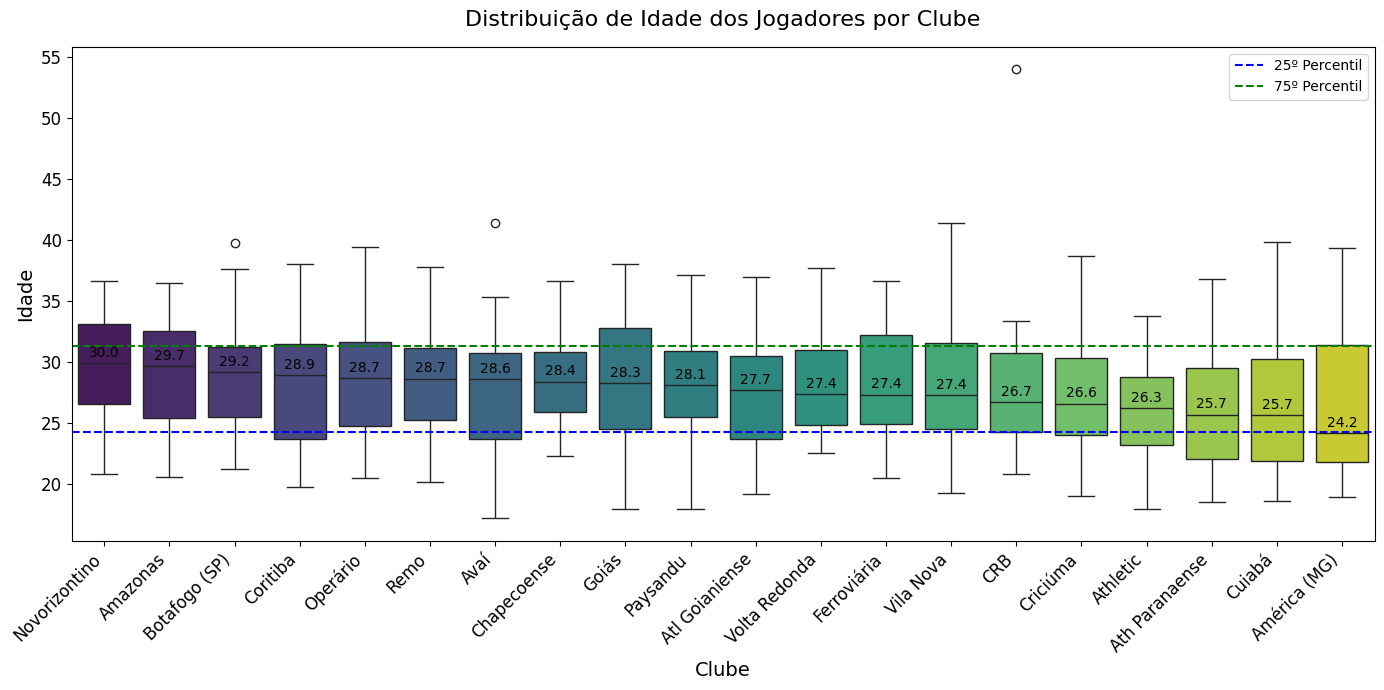

In [42]:
# Ordenar clubes pela mediana de idade
clubes_ordenados = (
    serie_b.groupby('Squad')['Age'].median()
    .sort_values(ascending=False)
    .index
)

# Criar a figura
plt.figure(figsize=(14, 7))

# Criar o boxplot com clubes ordenados e paleta personalizada
sns.boxplot(
    x='Squad', 
    y='Age', 
    data=serie_b, 
    palette='viridis', 
    order=clubes_ordenados, 
    showfliers=True  # Defina como False para ocultar outliers, se desejar
)

# Adicionar linhas dos quartis para melhor interpretação
plt.axhline(serie_b['Age'].quantile(0.25), color='blue', linestyle='--', label='25º Percentil')
plt.axhline(serie_b['Age'].quantile(0.75), color='green', linestyle='--', label='75º Percentil')
plt.legend()

# Adicionar anotações com a mediana de idade de cada clube
medianas_idade = serie_b.groupby('Squad')['Age'].median()
for indice, clube in enumerate(clubes_ordenados):
    plt.text(
        indice, 
        medianas_idade[clube] + 0.5,  # Posicionar o texto um pouco acima da mediana
        f"{medianas_idade[clube]:.1f}",  # Exibir mediana com 1 casa decimal
        ha='center', 
        fontsize=10, 
        color='black'
    )

# Personalizar título e rótulos
plt.title('Distribuição de Idade dos Jogadores por Clube', fontsize=16, pad=15)
plt.xlabel('Clube', fontsize=14)
plt.ylabel('Idade', fontsize=14)

# Ajustar rótulos dos eixos para melhor legibilidade
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [43]:
# Contar número de jogadores por clube
num_jogadores = serie_b.groupby('Squad').size()

# Calcular a média de idade por clube (soma das idades / número de jogadores)
media_idade_por_clube = (serie_b.groupby('Squad')['Age'].sum()) / num_jogadores

# Arredondar para 2 casas decimais
media_idade_por_clube = media_idade_por_clube.round(2)

# Ordenar os clubes pela média de idade (do mais velho para o mais jovem)
media_idade_por_clube.sort_values(ascending=False)

Squad
Novorizontino     29.68
Amazonas          28.96
Botafogo (SP)     28.88
Chapecoense       28.66
Coritiba          28.41
Volta Redonda     28.36
Goiás             28.35
Operário          28.33
Remo              28.27
Ferroviária       28.01
Paysandu          27.92
CRB               27.89
Avaí              27.52
Atl Goianiense    27.41
Vila Nova         27.25
Criciúma          27.19
América (MG)      26.54
Ath Paranaense    26.39
Cuiabá             26.3
Athletic          26.06
dtype: Float64

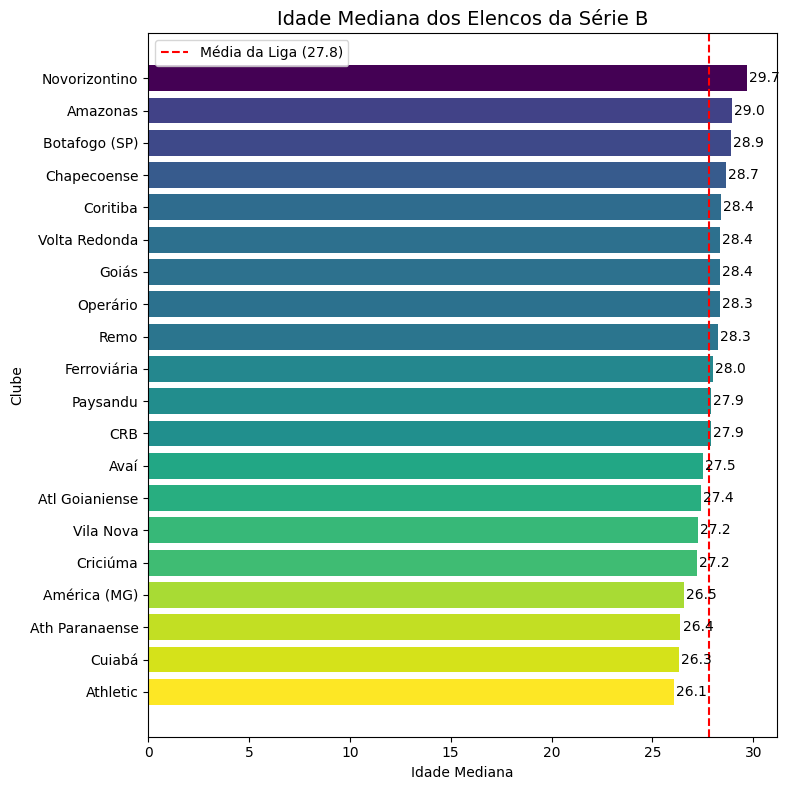

In [44]:
# Transformar em DataFrame
df_medianas = pd.DataFrame(list(media_idade_por_clube.items()), columns=["Clube", "Idade_Mediana"])

# Média da liga
media_liga = df_medianas["Idade_Mediana"].mean()

# Ordenar do mais jovem para o mais velho
df_ordenado = df_medianas.sort_values("Idade_Mediana", ascending=True)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

# Barras coloridas em gradiente
barras = ax.barh(
    df_ordenado["Clube"],
    df_ordenado["Idade_Mediana"],
    color=plt.cm.viridis_r(
        (df_ordenado["Idade_Mediana"] - df_ordenado["Idade_Mediana"].min()) /
        (df_ordenado["Idade_Mediana"].max() - df_ordenado["Idade_Mediana"].min())
    )
)

# Linha da média da liga
ax.axvline(media_liga, color="red", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série B", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout para evitar cortes
plt.tight_layout()

# Exibir o gráfico
plt.show()

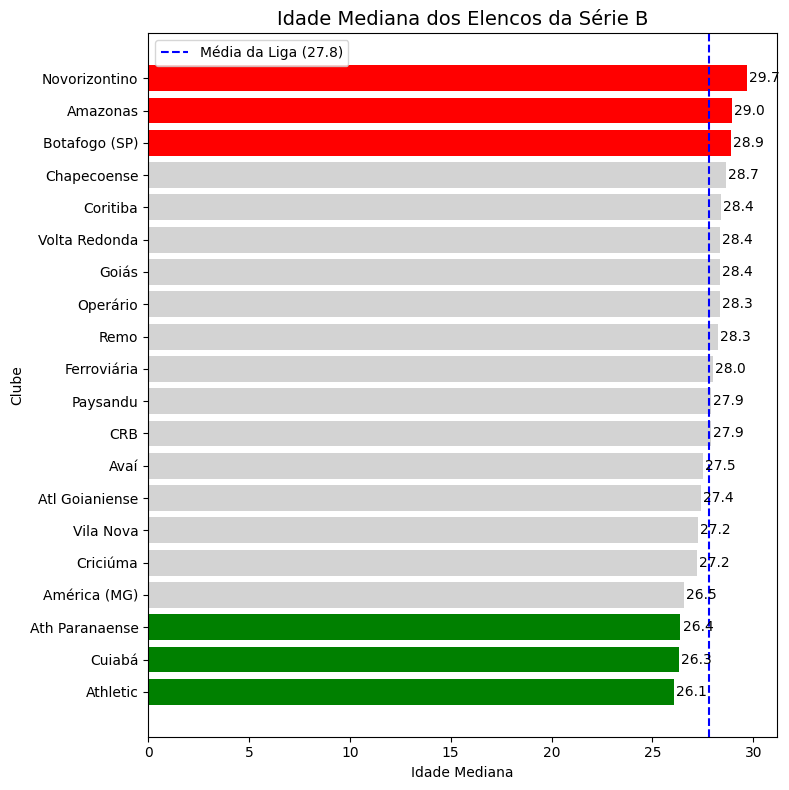

In [45]:
# Identificar top 3 clubes mais jovens e top 3 mais experientes
mais_jovens = df_ordenado.head(3)["Clube"].tolist()
mais_experientes = df_ordenado.tail(3)["Clube"].tolist()

# Definir cores para destaque
cores = []
for clube in df_ordenado["Clube"]:
    if clube in mais_jovens:
        cores.append("green")      # destaque para os mais jovens
    elif clube in mais_experientes:
        cores.append("red")        # destaque para os mais experientes
    else:
        cores.append("lightgray")  # cor neutra para os demais

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

barras = ax.barh(df_ordenado["Clube"], df_ordenado["Idade_Mediana"], color=cores)

# Linha da média da liga
ax.axvline(media_liga, color="blue", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série B", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


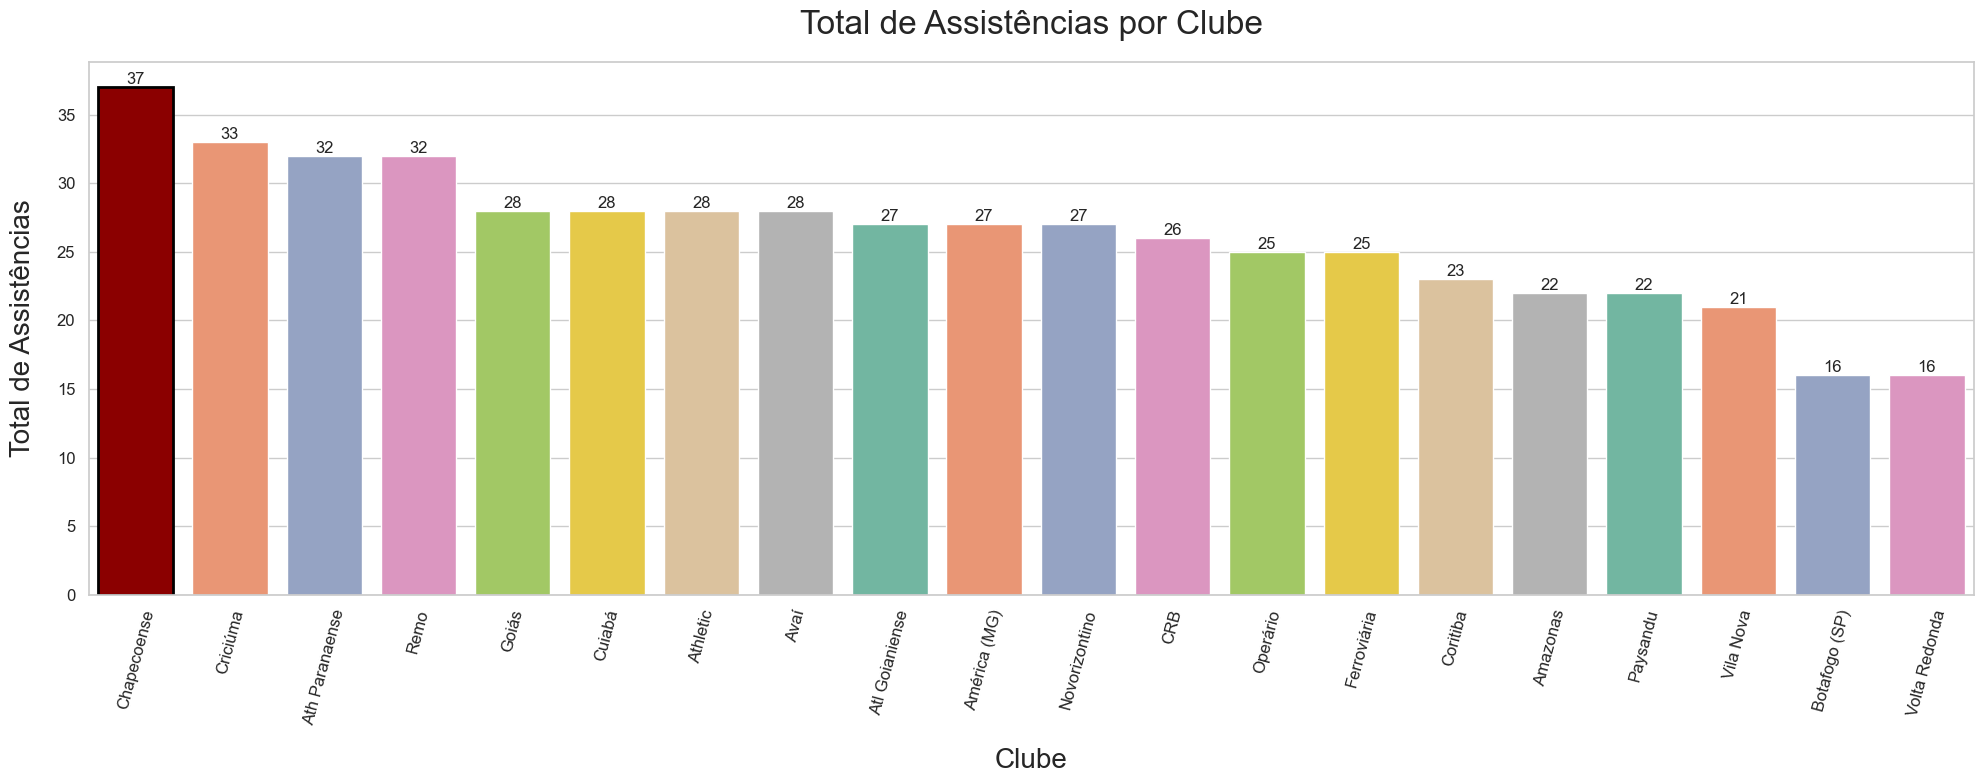

In [46]:
# Total de assistências por clube
Assistencias_por_clube = pd.DataFrame(serie_b.groupby('Squad', as_index=False)['Ast'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Ast', 
    data=Assistencias_por_clube.sort_values(by='Ast', ascending=False),  # Ordenar clubes por assistências
    palette='Set2'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Assistências', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Assistências por Clube', fontsize=24, pad=20)

# Destacar o primeiro clube (maior número de assistências)
ax.patches[0].set_facecolor('darkred')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [47]:
# Top 10 jogadores com mais assistências

top_10_assistencias = serie_b[['Player', 'Age', 'Squad', 'Ast', 'MP']].nlargest(n=10, columns='Ast')
top_10_assistencias

,Player,Age,Squad,Ast,MP
52,Giovanni Augusto,36.18,Chapecoense,10.0,30.0
88,Gabriel Boschilia,29.68,Operário,6.0,33.0
170,Danielzinho,29.83,CRB,6.0,33.0
249,Luiz Fernando,29.07,Ath Paranaense,6.0,31.0
269,Marquinhos Gabriel,35.31,Avaí,6.0,35.0
369,Juninho,30.19,Ferroviária,6.0,33.0
635,Reverson,28.77,Paysandu,6.0,31.0
796,Bruno Zapelli,23.48,Ath Paranaense,6.0,33.0
205,Mailton dos Santos,27.45,Chapecoense,5.0,20.0
227,Lucas Esquivel,24.07,Ath Paranaense,5.0,23.0


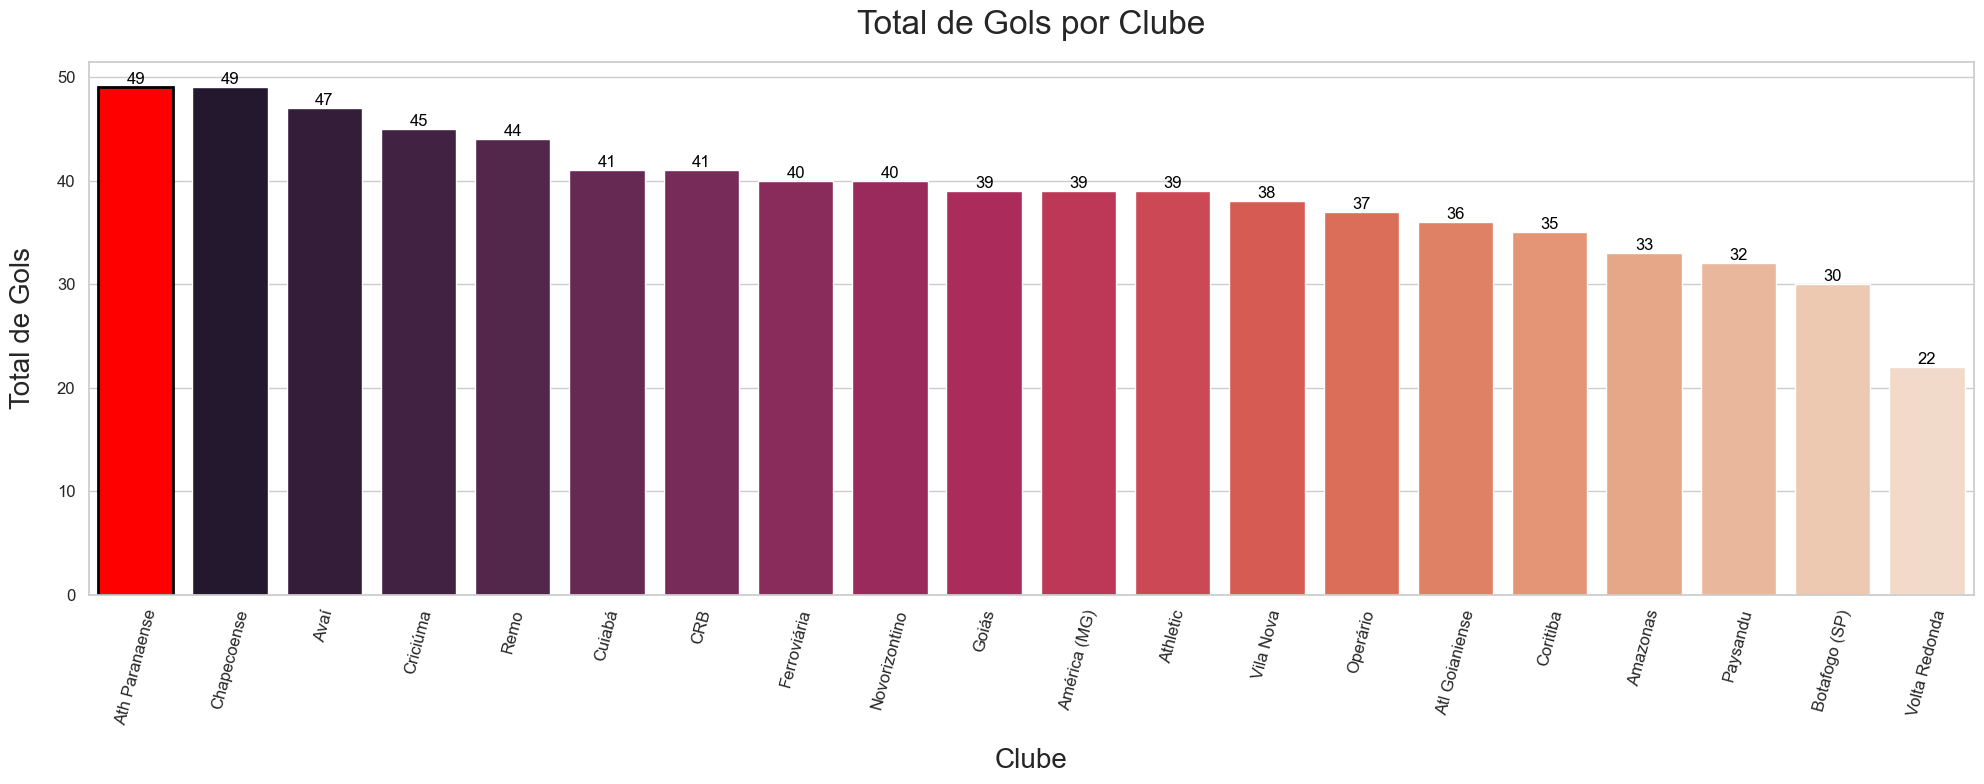

In [49]:
# Total de gols por clube
Gols_por_clube = pd.DataFrame(serie_b.groupby('Squad', as_index=False)['Gls'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Gls', 
    data=Gols_por_clube.sort_values(by='Gls', ascending=False),  # Ordenar clubes por gols
    palette='rocket'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),  # Formatar como número inteiro com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Gols', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Gols por Clube', fontsize=24, pad=20)

# Ajustar layout
plt.tight_layout()

# Destacar a primeira barra (maior número de gols)
ax.patches[0].set_facecolor('red')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Exibir o gráfico
plt.show()

In [67]:
import plotly.express as px
from IPython.display import HTML

# Mapeamento de cores por clube (para manter identidade visual)
cores_por_clube = {
    "Novorizontino": "gold",          # amarelo/preto
    "Amazonas": "yellow",             # amarelo
    "Botafogo (SP)": "red",           # vermelho/preto
    "Chapecoense": "forestgreen",     # verde
    "Coritiba": "limegreen",          # verde/branco
    "Volta Redonda": "black",         # preto/amarelo
    "Goiás": "green",                 # verde/branco
    "Operário": "dimgray",            # preto/branco
    "Remo": "navy",                   # azul marinho
    "Ferroviária": "maroon",          # grená
    "Paysandu": "deepskyblue",        # azul/branco
    "CRB": "crimson",                 # vermelho/branco
    "Avaí": "royalblue",              # azul/branco
    "Atl Goianiense": "red",     # vermelho/preto
    "Vila Nova": "darkred",           # vermelho/branco
    "Criciúma": "gold",               # amarelo/preto
    "América (MG)": "darkgreen",      # verde/preto
    "Ath Paranaense": "red",  # vermelho/preto
    "Cuiabá": "yellowgreen",          # verde/amarelo
    "Athletic": "silver"              # branco/preto (novo de MG)
}

# Criar gráfico de treemap: gols por clube
fig = px.treemap(
    serie_b,
    path=["Squad"],                # Agrupar por clube
    values="Gls",                  # Tamanho proporcional aos gols
    color="Squad",                 # Cor por clube
    color_discrete_map=cores_por_clube,  # Usar cores definidas acima
    width=1200,
    height=400,
    title="Total de Gols Marcados por Clube"  # Título traduzido
)

# Ajustar margens do gráfico
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.update_traces(textinfo="label+value")

# Renderizar gráfico de forma segura no notebook
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

In [58]:
# Jogadores com mais gols

top_10_gols = serie_b[['Player', 'Age', 'Squad', 'Gls', 'Ast', 'MP', 'Pos']].nlargest(n=10, columns=['Gls'])
top_10_gols

,Player,Age,Squad,Gls,Ast,MP,Pos
652,Pedro Rocha Neves,31.11,Remo,14.0,5.0,30.0,"MF,FW"
117,Carlão,33.36,Ferroviária,13.0,2.0,34.0,FW
147,Cléber,29.05,Avaí,11.0,4.0,35.0,FW
620,Kevin Ramírez,31.61,Amazonas,10.0,1.0,27.0,"MF,FW"
675,Safira,30.65,Cuiabá,10.0,2.0,22.0,FW
88,Gabriel Boschilia,29.68,Operário,9.0,6.0,33.0,"MF,FW"
289,Diego Gonçalves,31.3,Criciúma,9.0,3.0,35.0,"MF,FW"
622,Anselmo Ramon,37.38,Goiás,9.0,1.0,33.0,FW
731,Ronaldo Tavares,28.3,Athletic,9.0,5.0,24.0,FW
775,Kevin Viveros,25.6,Ath Paranaense,9.0,1.0,19.0,FW


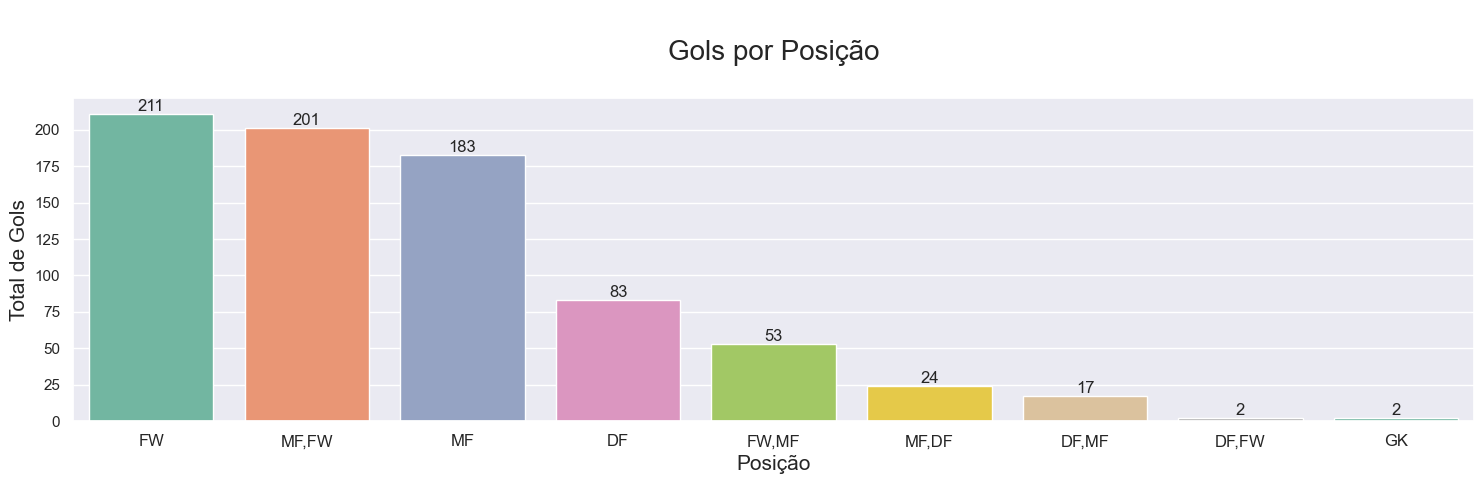

In [59]:
# Configurar estilo do Seaborn
sns.set(rc={'figure.figsize': (15, 5)})
plt.xticks(fontsize=12)

# Agrupar por posição e somar gols
serie_b_agrupado = serie_b.groupby('Pos', as_index=False)['Gls'].sum()

# Ordenar posições por total de gols (do maior para o menor)
serie_b_agrupado = serie_b_agrupado.sort_values(by='Gls', ascending=False)

# Criar gráfico de barras
p = sns.barplot(
    data=serie_b_agrupado, 
    x='Pos', 
    y='Gls', 
    palette="Set2"
)

# Adicionar valores no topo das barras
for barra in p.patches:
    p.annotate(
        format(int(barra.get_height()), ','),  # Formatar valor com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Adicionar título e rótulos dos eixos
p.axes.set_title("\nGols por Posição\n", fontsize=20)
p.set_xlabel("Posição", fontsize=15)
p.set_ylabel("Total de Gols", fontsize=15)

# Melhorar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [62]:
# Criar 2 novas colunas
serie_b['MinutosPorJogo'] = (serie_b['Min'] / serie_b['MP']).fillna(0).astype(int)
serie_b['GolsPorJogo'] = (serie_b['Gls'] / serie_b['MP']).fillna(0).astype(float)
print(serie_b)

      Rk                           Player  Nation    Pos           Squad  \
0      1                    Sabit Abdulai  gh GHA     MF   Botafogo (SP)   
1      2                         Adaílton  br BRA  FW,MF            Remo   
2      3                      Lucas Adell  br BRA     DF   Volta Redonda   
3      4                        Ademilson  br BRA  FW,MF        Operário   
4      5                           Adriel  br BRA     GK        Athletic   
5      6                           Adsson  br BRA     MF   Volta Redonda   
6      7                           Airton  br BRA  MF,FW   Novorizontino   
7      8                     Marcelo Ajul  br BRA     DF        Athletic   
8      9                     Carlos Akapo  gq EQG  DF,MF        Amazonas   
9     10                        Léo Alaba  br BRA  DF,MF        Criciúma   
10    11                           Albano  br BRA  MF,FW     Ferroviária   
11    12                   Carlos Alberto  br BRA  MF,FW          Cuiabá   
12    13    

In [63]:
# Gols por jogo
# Filtrar jogadores com mais de 10 jogos disputados

acima_10_jogos = serie_b[serie_b['MP'] > 10]
top_10_gols_por_jogo = acima_10_jogos[['Player', 'Age', 'Squad', 'MP', 'Min', 'Gls', 'GolsPorJogo']].nlargest(n=10, columns='GolsPorJogo')
top_10_gols_por_jogo

,Player,Age,Squad,MP,Min,Gls,GolsPorJogo
775,Kevin Viveros,25.6,Ath Paranaense,19.0,1479.0,9.0,0.473684
652,Pedro Rocha Neves,31.11,Remo,30.0,2482.0,14.0,0.466667
675,Safira,30.65,Cuiabá,22.0,1576.0,10.0,0.454545
260,Nathan Fogaça,26.42,Novorizontino,15.0,824.0,6.0,0.400000
393,Lelê,28.11,Atl Goianiense,15.0,1225.0,6.0,0.400000
117,Carlão,33.36,Ferroviária,34.0,2894.0,13.0,0.382353
731,Ronaldo Tavares,28.3,Athletic,24.0,1755.0,9.0,0.375000
620,Kevin Ramírez,31.61,Amazonas,27.0,2062.0,10.0,0.370370
365,Julimar,24.79,Ath Paranaense,11.0,560.0,4.0,0.363636
198,Diogo,28.93,Paysandu,17.0,1264.0,6.0,0.352941


In [64]:
top_10_gols_por_jogo[['Player', 'Squad', 'MP', 'Gls', 'GolsPorJogo']].style \
    .set_caption("Top 10 Jogadores em Gols por Jogo (Mín. 11 Jogos)") \
    .format({'GolsPorJogo': "{:.2f}"}) \
    .set_properties(**{'text-align': 'center', 'background-color': "#070707"})

,Player,Squad,MP,Gls,GolsPorJogo
775,Kevin Viveros,Ath Paranaense,19.000000,9.000000,0.47
652,Pedro Rocha Neves,Remo,30.000000,14.000000,0.47
675,Safira,Cuiabá,22.000000,10.000000,0.45
260,Nathan Fogaça,Novorizontino,15.000000,6.000000,0.40
393,Lelê,Atl Goianiense,15.000000,6.000000,0.40
117,Carlão,Ferroviária,34.000000,13.000000,0.38
731,Ronaldo Tavares,Athletic,24.000000,9.000000,0.38
620,Kevin Ramírez,Amazonas,27.000000,10.000000,0.37
365,Julimar,Ath Paranaense,11.000000,4.000000,0.36
198,Diogo,Paysandu,17.000000,6.000000,0.35


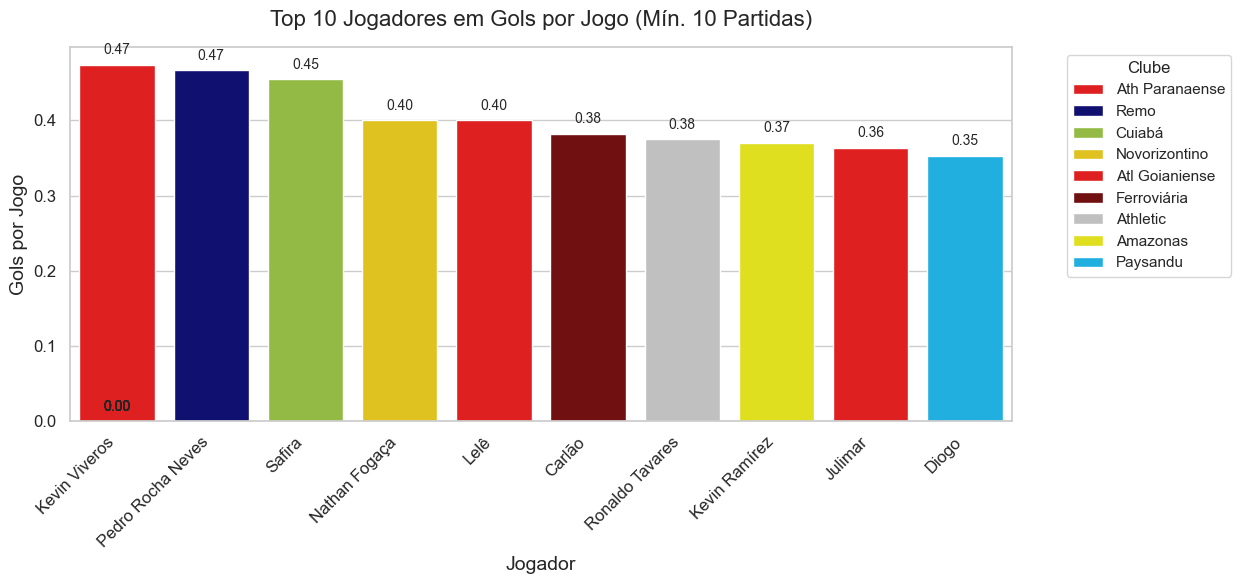

In [68]:
# Filtrar jogadores com mais de 10 partidas jogadas
acima_10_partidas = serie_b[serie_b['MP'] > 10]

# Selecionar os 10 jogadores com melhor desempenho em GolsPorJogo
top_10_gols_por_jogo = acima_10_partidas[['Player', 'Squad', 'GolsPorJogo', 'MP', 'Gls']].nlargest(n=10, columns='GolsPorJogo')

# Plotar gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")


# Criar gráfico
ax = sns.barplot(
    data=top_10_gols_por_jogo,
    x='Player',
    y='GolsPorJogo',
    hue='Squad',
    palette=cores_por_clube,
    dodge=False
)

# Adicionar valores no topo das barras (corrigido)
for barra in ax.patches:
    valor = barra.get_height()
    valor_formatado = f"{valor:.2f}"  # Garante 2 casas decimais
    ax.annotate(
        valor_formatado,
        (barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.01),
        ha='center', va='bottom', fontsize=10
    )

# Personalizar título e rótulos
ax.set_title('Top 10 Jogadores em Gols por Jogo (Mín. 10 Partidas)', fontsize=16, pad=15)
ax.set_xlabel('Jogador', fontsize=14)
ax.set_ylabel('Gols por Jogo', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Legenda fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

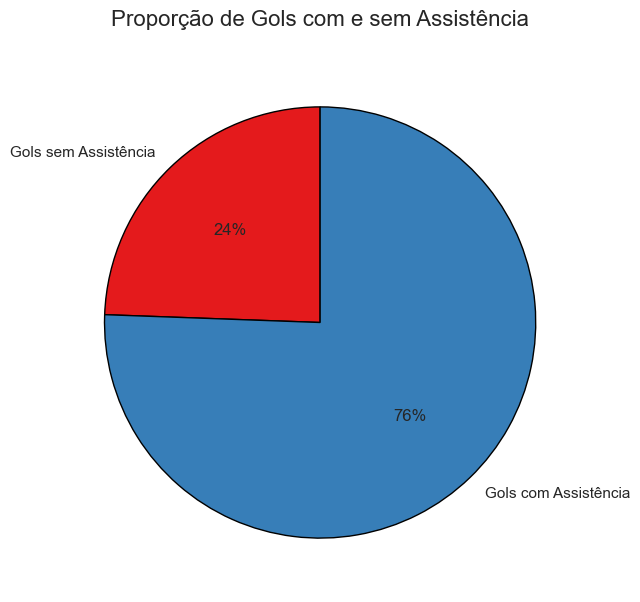

In [69]:
# Dados para o gráfico de pizza
assistencias = serie_b['Ast'].sum()
dados = [Total_Gols - assistencias, assistencias]
rotulos = ['Gols sem Assistência', 'Gols com Assistência']
cores = sns.color_palette('Set1')

# Criar gráfico de pizza
plt.figure(figsize=(14, 7))
plt.pie(
    dados, 
    labels=rotulos, 
    colors=cores, 
    autopct='%.0f%%', 
    startangle=90,  # Iniciar o gráfico no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar bordas pretas para melhor contraste
)

# Adicionar título
plt.title('Proporção de Gols com e sem Assistência', fontsize=16, pad=20)

# Exibir o gráfico
plt.show()

In [71]:
import plotly.express as px
from IPython.display import HTML

# Filtrar atacantes com pelo menos 900 minutos jogados
atacantes = serie_b[serie_b['Min'] >= 900]

# Criando o gráfico de dispersão
fig = px.scatter(
    atacantes,
    x="Gls_90",      # Eixo X: Gols por 90 minutos
    y="Ast_90",       # Eixo Y: xG (Expected Goals) por 90 minutos
    text="Player",   # Exibir nome dos jogadores nos pontos
    title="Relação entre Gols Marcados e xG por 90 Minutos",
    labels={
        "xG_90": "xG por 90 min (Gols Esperados)",
        "Gls_90": "Gols por 90 min"
    },
    template="plotly_white"
)

# Adicionar linha de referência: xG = Gols
fig.add_shape(
    type="line", line=dict(dash='dash', color='gray'),
    x0=atacantes['Gls_90'].min(), y0=atacantes['Gls_90'].min(),
    x1=atacantes['Gls_90'].max(), y1=atacantes['Gls_90'].max()
)

# Adicionar anotação na linha
fig.add_annotation(
    x=atacantes['Gls_90'].max() - 0.5,
    y=atacantes['Gls_90'].max() - 0.5,
    text="xG = Gols",
    showarrow=False,
    font=dict(size=12, color="gray")
)


# Ajustando posição do texto (nome dos jogadores)
fig.update_traces(textposition="top center")

# Exibir gráfico inline sem depender de renderizador externo
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

In [72]:
# Ordenar o dataset por 'PrgC' em ordem decrescente
serie_b = serie_b.sort_values(by='PrgC', ascending=False)

# Selecionar os 15 melhores jogadores
top_dribladores = serie_b[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico de barras sem barras de erro
ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'), 
        (barra.get_x() + barra.get_width() / 2, barra.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Dribladores da Série A\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Carregadas Progressivas (PrgC)", fontsize=14)

ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

KeyError: 'PrgC'

In [73]:
# Ordenar o dataset por 'PrgP' em ordem decrescente
serie_b = serie_b.sort_values(by='PrgP', ascending=False)

# Selecionar os 15 melhores jogadores
top_passadores = serie_b[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)  # Rotacionar rótulos do eixo X para melhor legibilidade

# Criar gráfico de barras
ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'),  # Exibir valor com uma casa decimal
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Jogadores em Passes Progressivos (PrgP)\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Passes Progressivos (PrgP)", fontsize=14)


ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)  # Dar espaço para a legenda


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

KeyError: 'PrgP'

In [74]:
serie_b.columns.to_list()

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'MinutosPorJogo',
 'GolsPorJogo']

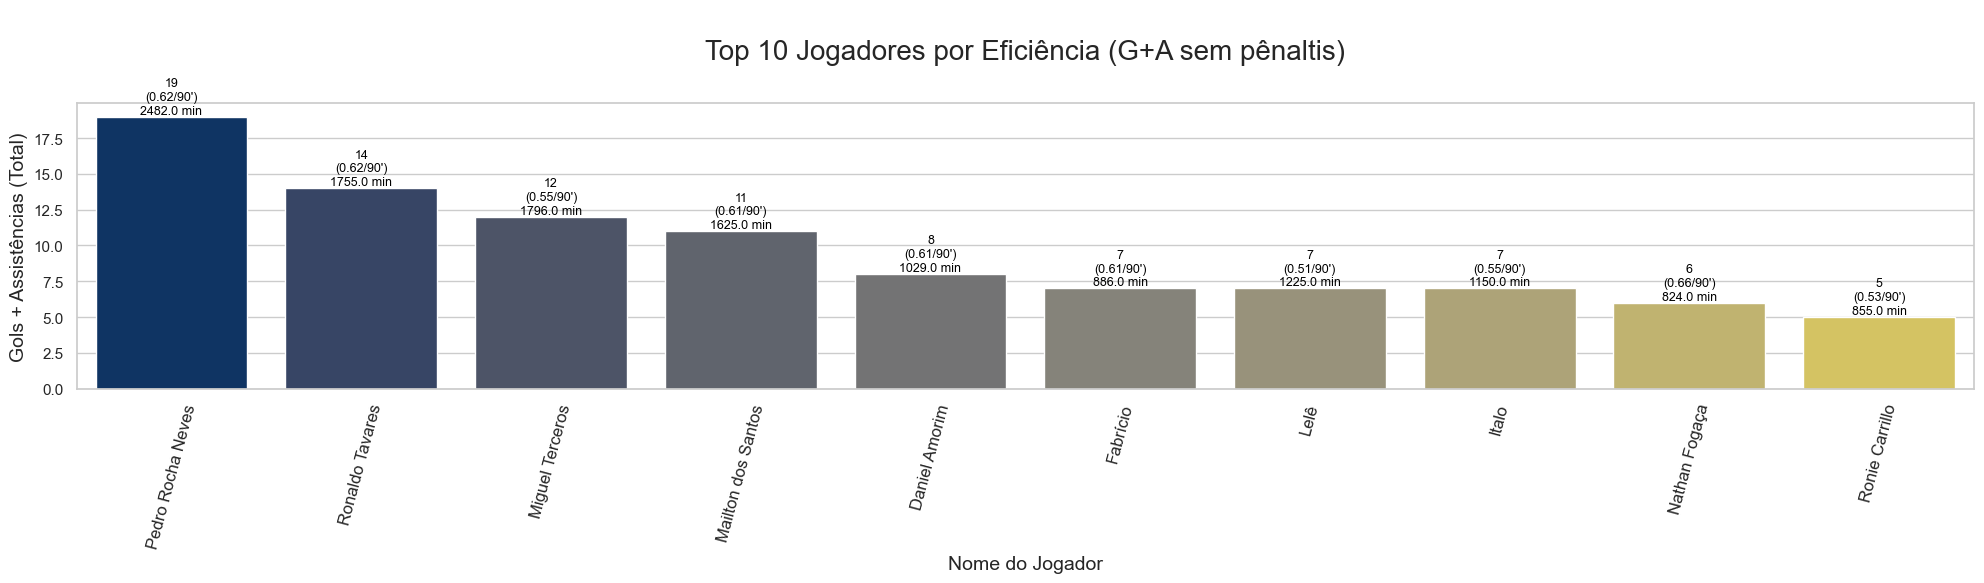

In [75]:
# Criar coluna G+A (se ainda não existir)
serie_b['G+A'] = serie_b['Gls'] + serie_b['Ast']

# Filtrar jogadores com pelo menos 8 jogos (90s >= 8)
serie_b_filtrada = serie_b[serie_b['90s'] >= 8]

# Ordenar por eficiência (G+A-PK_90) — para selecionar os mais eficientes
serie_b_ordenada = serie_b_filtrada.sort_values(by='G+A-PK_90', ascending=False)

# Selecionar os 10 melhores
top_jogadores = serie_b_ordenada.head(10)

# Reordenar por G+A total (para exibição visual)
top_jogadores_ordem_plot = top_jogadores.sort_values(by='G+A', ascending=False)

# Configurar estilo
sns.set_theme(style="whitegrid", rc={'figure.figsize': (20, 6)})
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico
ax = sns.barplot(
    x="Player",
    y="G+A",
    data=top_jogadores_ordem_plot,
    palette="cividis"
)

# Adicionar valores totais e eficiência
for i, barra in enumerate(ax.patches):
    jogador = top_jogadores_ordem_plot.iloc[i]
    valor_total = barra.get_height()
    eficiencia = jogador['G+A-PK_90']
    minutos = jogador['Min']
    
    ax.annotate(
        f"{valor_total:.0f}\n({eficiencia:.2f}/90')\n{minutos} min",
        (barra.get_x() + barra.get_width() / 2, valor_total),
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Título e rótulos
ax.set_title("\nTop 10 Jogadores por Eficiência (G+A sem pênaltis)\n", fontsize=20, pad=10)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Gols + Assistências (Total)", fontsize=14)

plt.tight_layout()
plt.show()

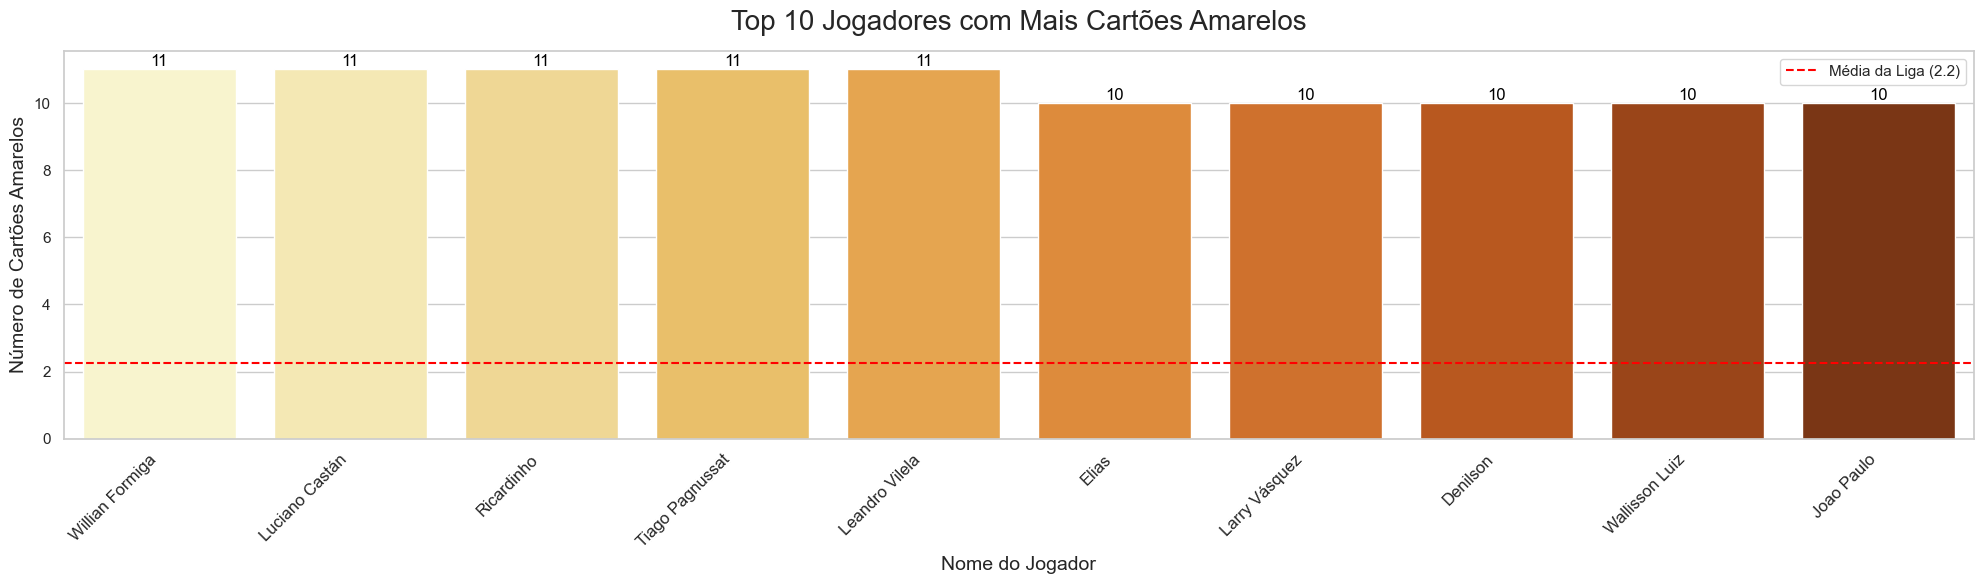

In [76]:
# Ordenar o dataset por cartões amarelos e selecionar os 10 jogadores com mais cartões
serie_b_amarelos = serie_b.sort_values(by='CrdY', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_b_amarelos['Player'], 
    y=serie_b_amarelos['CrdY'], 
    palette="YlOrBr"  # Paleta de cores em gradiente amarelo/laranja (temática de cartões)
)

# Adicionar anotações com o número de cartões amarelos
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir contagem de cartões como número inteiro
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar acima da barra
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Amarelos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Amarelos', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

media_liga = serie_b['CrdY'].mean()
ax.axhline(media_liga, color='red', linestyle='--', label=f'Média da Liga ({media_liga:.1f})')
ax.legend()

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [77]:
serie_b_amarelos

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,MinutosPorJogo,GolsPorJogo
261,262,Willian Formiga,br BRA,DF,Vila Nova,30.8,1995,27.0,27.0,2300.0,25.6,0.0,0.0,0.0,0.0,0.0,0.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,85,0.000000
129,130,Luciano Castán,br BRA,DF,Criciúma,36.16,1989,33.0,33.0,2959.0,32.9,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,89,0.000000
640,641,Ricardinho,br BRA,MF,Ferroviária,36.62,1989,31.0,30.0,2537.0,28.2,1.0,0.0,1.0,1.0,0.0,0.0,11.0,1.0,0.04,0.0,0.04,0.04,0.04,81,0.032258
553,554,Tiago Pagnussat,br BRA,DF,Vila Nova,35.4,1990,32.0,32.0,2590.0,28.8,1.0,0.0,1.0,1.0,0.0,0.0,11.0,1.0,0.03,0.0,0.03,0.03,0.03,80,0.031250
763,764,Leandro Vilela,br BRA,MF,Paysandu,30.37,1995,19.0,19.0,1478.0,16.4,2.0,0.0,2.0,2.0,0.0,0.0,11.0,1.0,0.12,0.0,0.12,0.12,0.12,77,0.105263
219,220,Elias,br BRA,DF,Vila Nova,26.32,1999,33.0,33.0,2878.0,32.0,1.0,0.0,1.0,1.0,0.0,0.0,10.0,1.0,0.03,0.0,0.03,0.03,0.03,87,0.030303
757,758,Larry Vásquez,ve VEN,MF,Amazonas,34.14,1991,29.0,27.0,2322.0,25.8,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,80,0.000000
185,186,Denilson,br BRA,MF,Cuiabá,24.64,2001,33.0,33.0,2607.0,29.0,0.0,1.0,1.0,0.0,0.0,0.0,10.0,0.0,0.0,0.03,0.03,0.0,0.03,79,0.000000
425,426,Wallisson Luiz,br BRA,MF,Coritiba,28.13,1997,29.0,17.0,1361.0,15.1,1.0,0.0,1.0,1.0,0.0,0.0,10.0,0.0,0.07,0.0,0.07,0.07,0.07,46,0.034483
576,577,Joao Paulo,br BRA,DF,Chapecoense,28.35,1997,31.0,31.0,2585.0,28.7,1.0,0.0,1.0,1.0,0.0,0.0,10.0,0.0,0.03,0.0,0.03,0.03,0.03,83,0.032258


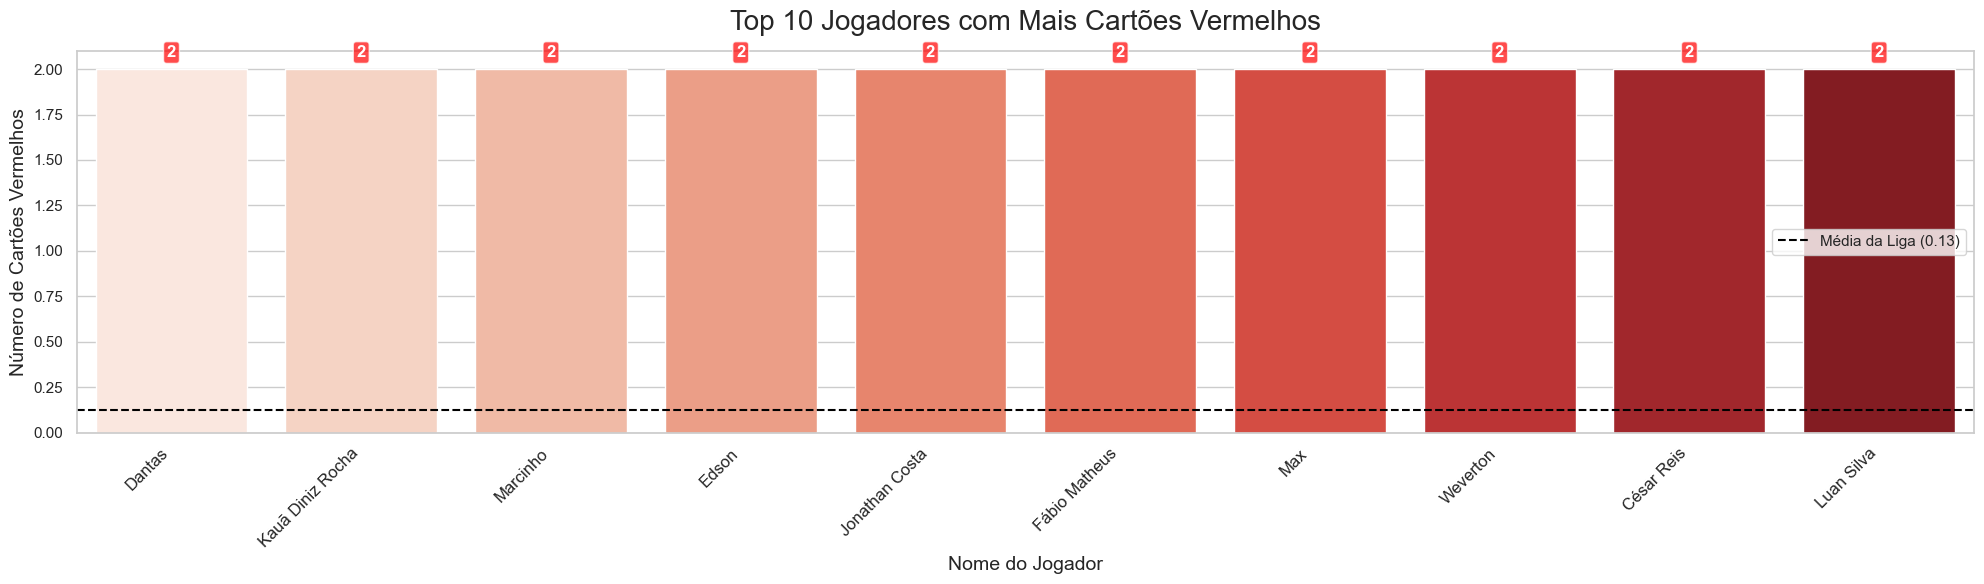

In [78]:
# Ordenar o dataset por cartões vermelhos e selecionar os 10 jogadores com mais cartões
serie_b_vermelhos = serie_b.sort_values(by='CrdR', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_b_vermelhos['Player'], 
    y=serie_b_vermelhos['CrdR'], 
    palette="Reds"  # Paleta de gradiente vermelho
)

# Adicionar anotações com o número de cartões vermelhos — POSICIONADAS ACIMA DA BARRA
for barra in ax.patches:
    altura = barra.get_height()
    # Posicionar o texto UM POUCO ACIMA da barra para melhor visibilidade
    ax.annotate(
        f'{int(altura)}',  # Número inteiro de cartões
        (barra.get_x() + barra.get_width() / 2, altura + 0.05),  # 👈 Deslocamento vertical +0.05
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="red", alpha=0.7)  # Fundo arredondado para destacar
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Vermelhos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Vermelhos', fontsize=14)

# Adicionar linha da média da liga
media_liga = serie_b['CrdR'].mean()
ax.axhline(media_liga, color='black', linestyle='--', label=f'Média da Liga ({media_liga:.2f})')
ax.legend()

# Rotacionar rótulos do eixo X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [79]:
serie_b_vermelhos

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,MinutosPorJogo,GolsPorJogo
171,172,Dantas,br BRA,DF,Novorizontino,21.3,2004,24.0,24.0,2031.0,22.6,2.0,0.0,2.0,2.0,0.0,0.0,8.0,2.0,0.09,0.0,0.09,0.09,0.09,84,0.083333
196,197,Kauã Diniz Rocha,br BRA,MF,América (MG),21.68,2004,24.0,15.0,1444.0,16.0,2.0,0.0,2.0,2.0,0.0,0.0,8.0,2.0,0.12,0.0,0.12,0.12,0.12,60,0.083333
448,449,Marcinho,br BRA,"MF,DF",Criciúma,29.49,1996,28.0,27.0,2251.0,25.0,2.0,5.0,7.0,2.0,0.0,0.0,8.0,2.0,0.08,0.2,0.28,0.08,0.28,80,0.071429
214,215,Edson,br BRA,DF,Botafogo (SP),34.36,1991,16.0,12.0,1024.0,11.4,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,64,0.000000
155,156,Jonathan Costa,br BRA,DF,Avaí,30.56,1995,29.0,29.0,2408.0,26.8,1.0,1.0,2.0,1.0,0.0,0.0,7.0,2.0,0.04,0.04,0.07,0.04,0.07,83,0.034483
475,476,Fábio Matheus,br BRA,"MF,DF",Novorizontino,22.58,2003,27.0,24.0,2074.0,23.0,0.0,1.0,1.0,0.0,0.0,0.0,8.0,2.0,0.0,0.04,0.04,0.0,0.04,76,0.000000
479,480,Max,br BRA,"MF,FW",Cuiabá,24.5,2001,30.0,27.0,2317.0,25.7,2.0,4.0,6.0,2.0,0.0,0.0,5.0,2.0,0.08,0.16,0.23,0.08,0.23,77,0.066667
786,787,Weverton,br BRA,DF,Vila Nova,22.73,2003,17.0,15.0,1397.0,15.5,1.0,0.0,1.0,1.0,0.0,0.0,6.0,2.0,0.06,0.0,0.06,0.06,0.06,82,0.058824
631,632,César Reis,br BRA,GK,Avaí,30.73,1995,21.0,21.0,1888.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,89,0.000000
706,707,Luan Silva,br BRA,"FW,MF",Amazonas,33.31,1992,22.0,10.0,1119.0,12.4,5.0,2.0,7.0,3.0,2.0,2.0,4.0,2.0,0.4,0.16,0.56,0.24,0.4,50,0.227273


## Jogadores com mais partidas

In [80]:
# Quantos jogos cada clube já disputou
jogos_por_time = serie_b.groupby("Squad")["MP"].max().sort_values(ascending=False)

print(jogos_por_time)


Squad
Coritiba          36.0
Ferroviária       36.0
CRB               36.0
América (MG)      35.0
Remo              35.0
Vila Nova         35.0
Goiás             35.0
Chapecoense       35.0
Criciúma          35.0
Avaí              35.0
Athletic          34.0
Ath Paranaense    33.0
Cuiabá            33.0
Operário          33.0
Novorizontino     33.0
Atl Goianiense    32.0
Botafogo (SP)     32.0
Paysandu          31.0
Volta Redonda     31.0
Amazonas          29.0
Name: MP, dtype: Float64


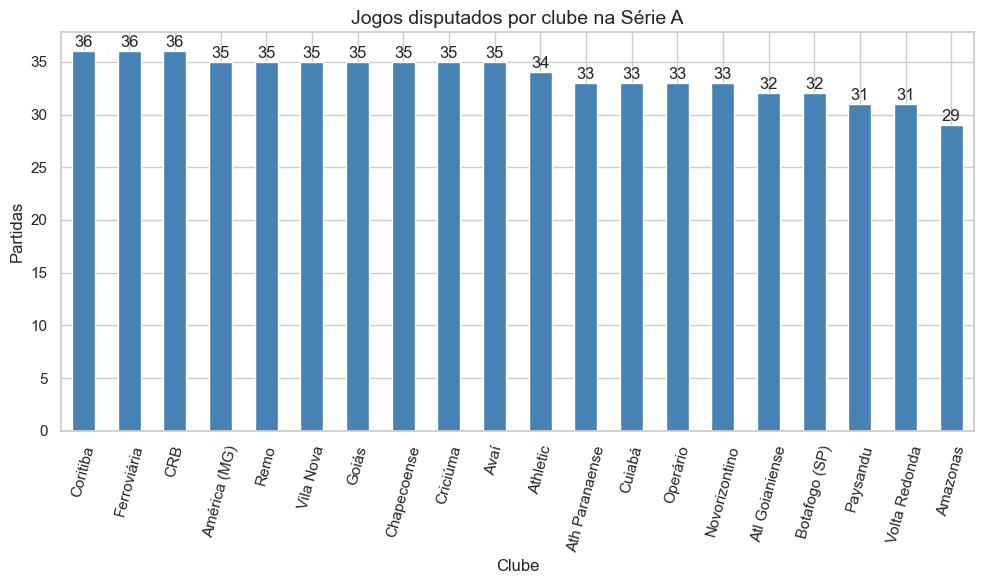

In [81]:
import matplotlib.pyplot as plt

jogos_por_time = serie_b.groupby("Squad")["MP"].max().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10,6))
jogos_por_time.plot(kind="bar", color="steelblue", ax=ax)

# Adicionar rótulos em cima
for i, v in enumerate(jogos_por_time):
    ax.text(i, v + 0.1, str(int(v)), ha='center', va='bottom')

ax.set_title("Jogos disputados por clube na Série A", fontsize=14)
ax.set_ylabel("Partidas")
ax.set_xlabel("Clube")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


In [82]:
# Top jogadores com mais jogos
top_jogadores = serie_b.sort_values("Min", ascending=False)[["Player","Pos","Squad","MP","Min"]]

print(top_jogadores.head(15))


                    Player    Pos         Squad    MP     Min
186           Júnior Dênis     GK   Ferroviária  36.0  3240.0
409                  Lucão     DF  América (MG)  35.0  3150.0
723                  Tadeu     GK         Goiás  35.0  3150.0
93           Eduardo Brock     DF          Avaí  35.0  3136.0
144            Walter Clar  MF,DF   Chapecoense  35.0  3118.0
269     Marquinhos Gabriel     MF          Avaí  35.0  3093.0
625         Marcelo Rangel     GK          Remo  35.0  3065.0
12          Matheus Albino     GK           CRB  34.0  3060.0
307                  Henri     DF           CRB  34.0  3060.0
238       Rodrigo Fagundes     DF      Criciúma  34.0  3044.0
638        Matheus Ribeiro     DF           CRB  36.0  3043.0
464  Elias Martello Curzel     GK      Operário  33.0  2970.0
301                  Halls     GK     Vila Nova  33.0  2970.0
696                Sidimar     DF      Athletic  34.0  2968.0
129         Luciano Castán     DF      Criciúma  33.0  2959.0


In [ ]:
# Média de jogos por posição
jogos_por_pos = serie_b.groupby("Pos")["MP"].mean().sort_values(ascending=False)
print(jogos_por_pos.round(2))


Pos
FW,MF    14.12
MF,FW    13.12
MF       12.54
GK        12.3
DF        12.0
FW       11.67
MF,DF    11.21
DF,FW      9.5
DF,MF      9.0
FW,DF      7.4
Name: MP, dtype: Float64


In [ ]:
import pandas as pd

def top_n_jogos_por_pos(df, n=5, min_minutos=0):
    d = df.copy()

    # garantir tipos numéricos
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")

    # normalizar posição (pega a primeira da lista)
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )

    # filtro opcional por minutos
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # ordenar por posição, depois MP e Min (desempate)
    d = d.sort_values(["Pos_simple", "MP", "Min"], ascending=[True, False, False])

    # pegar top N por posição
    out = (d.groupby("Pos_simple")
             .head(n)[["Pos_simple", "Player", "Squad", "MP", "Min"]]
             .reset_index(drop=True))
    return out

top5_por_pos = top_n_jogos_por_pos(serie_b, n=5, min_minutos=0)

for pos, bloco in top5_por_pos.groupby("Pos_simple"):
    print(f"\n=== {pos} ===")
    print(bloco.drop(columns="Pos_simple").reset_index(drop=True).to_string(index=False))



=== DF ===
         Player            Squad    MP     Min
         Jemmes         Mirassol  29.0  2610.0
       Reinaldo         Mirassol  28.0  2427.0
        Vitinho    Botafogo (RJ)  28.0  2174.0
       Natanael Atlético Mineiro  28.0  1886.0
Willian Machado            Ceará  27.0  2409.0

=== FW ===
              Player         Squad    MP     Min
Nuno Gonçalo Moreira Vasco da Gama  29.0  2094.0
     Antonio Galeano         Ceará  28.0  2332.0
         Rayan Vitor Vasco da Gama  27.0  2211.0
  Chrystian Barletta  Sport Recife  27.0  1341.0
          Pedro Raul         Ceará  26.0  2239.0

=== GK ===
        Player         Squad    MP     Min
 Lucas Arcanjo       Vitória  28.0  2520.0
         Fábio    Fluminense  28.0  2520.0
 Agustín Rossi      Flamengo  28.0  2520.0
    Léo Jardim Vasco da Gama  28.0  2515.0
Gabriel Brazão        Santos  28.0  2497.0

=== MF ===
         Player            Squad    MP     Min
    Danielzinho         Mirassol  28.0  2496.0
 Gustavo Scarpa Atlético

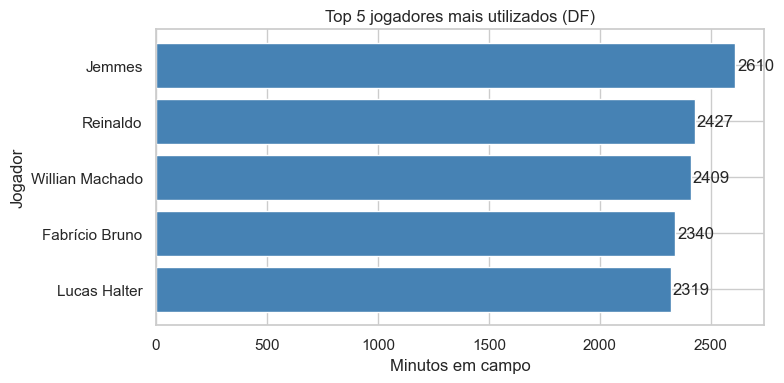

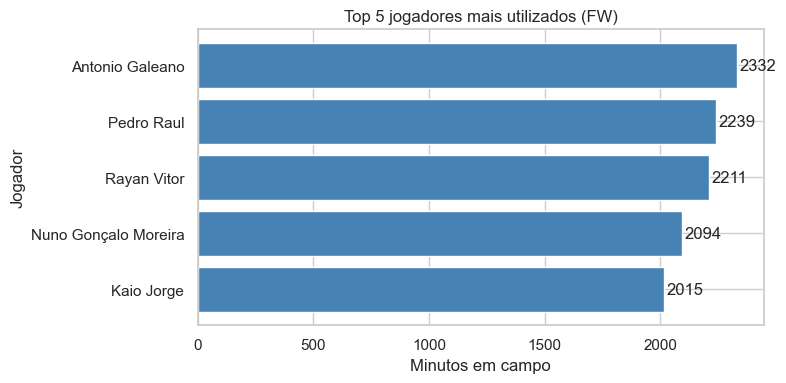

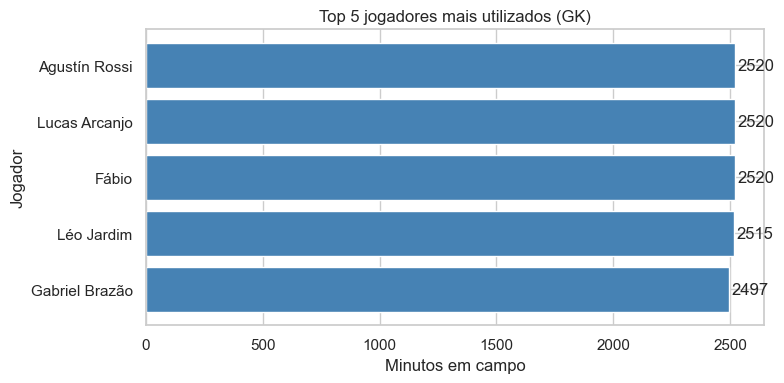

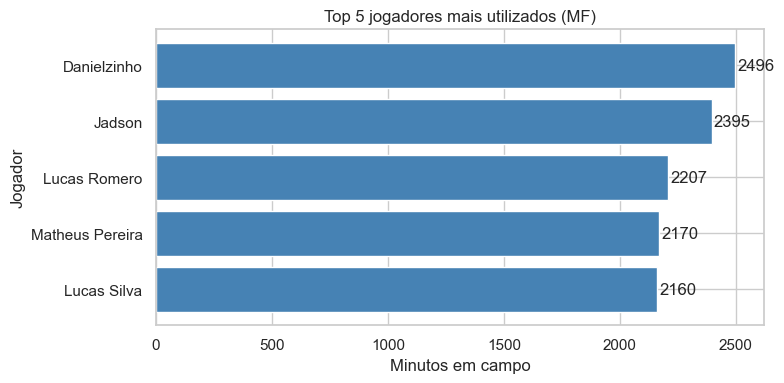

In [ ]:
import matplotlib.pyplot as plt

def plot_top5_por_pos(df, n=5, min_minutos=0):
    d = df.copy()
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # Ordenar por posição e minutos
    d = d.sort_values(["Pos_simple","Min"], ascending=[True,False])

    # Top N por posição
    top5 = d.groupby("Pos_simple").head(n)

    # Plotar cada posição separada
    posicoes = top5["Pos_simple"].unique()
    for pos in posicoes:
        bloco = top5[top5["Pos_simple"] == pos].sort_values("Min", ascending=True)

        plt.figure(figsize=(8,4))
        plt.barh(bloco["Player"], bloco["Min"], color="steelblue")
        plt.title(f"Top {n} jogadores mais utilizados ({pos})")
        plt.xlabel("Minutos em campo")
        plt.ylabel("Jogador")

        # rótulos nos valores
        for i, v in enumerate(bloco["Min"]):
            plt.text(v + 10, i, str(int(v)), va="center")

        plt.tight_layout()
        plt.show()

# Executar
plot_top5_por_pos(serie_b, n=5, min_minutos=900)


In [ ]:
df_goleiros = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\goalkepper_stats.csv', sep=',')
df_goleiros.head(2)

In [ ]:
# Converter a coluna 'Saves' para numérico (forçando erros a virarem NaN)
df_goleiros['Saves'] = pd.to_numeric(df_goleiros['Saves'], errors='coerce')


top_2_saves = df_goleiros.nlargest(2, 'Saves')

# Exibir apenas as colunas relevantes
print(top_2_saves[['Player', 'Squad', 'Saves']])